# Machine Learning Engineer Nanodegree
## Model Evaluation & Validation

**Summary: ** Exploring data with pandas, numpy and pyplot, make predictions with a scikit-learn, evaluate using R_2, k-fold cross-validation, learning curves, complexity curves, GridSearchCV, RandomizedSearchCV and more

**Books: ** 
Python Machine Learning by Sebastian Raschka
https://github.com/rasbt/python-machine-learning-book
Machine Learning in Python by Michael Bowles

## Project: Predicting Boston Housing Prices

Welcome to the first project of the Machine Learning Engineer Nanodegree! In this notebook, some template code has already been provided for you, and you will need to implement additional functionality to successfully complete this project. You will not need to modify the included code beyond what is requested. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a 'TODO' statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

## Getting Started
In this project, you will evaluate the performance and predictive power of a model that has been trained and tested on data collected from homes in suburbs of Boston, Massachusetts. A model trained on this data that is seen as a *good fit* could then be used to make certain predictions about a home — in particular, its monetary value. This model would prove to be invaluable for someone like a real estate agent who could make use of such information on a daily basis.

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Housing). The Boston housing data was collected in 1978 and each of the 506 entries represent aggregated data about 14 features for homes from various suburbs in Boston, Massachusetts. For the purposes of this project, the following preprocessing steps have been made to the dataset:
- 16 data points have an `'MEDV'` value of 50.0. These data points likely contain **missing or censored values** and have been removed.
- 1 data point has an `'RM'` value of 8.78. This data point can be considered an **outlier** and has been removed.
- The features `'RM'`, `'LSTAT'`, `'PTRATIO'`, and `'MEDV'` are essential. The remaining **non-relevant features** have been excluded.
- The feature `'MEDV'` has been **multiplicatively scaled** to account for 35 years of market inflation.

Run the code cell below to load the Boston housing dataset, along with a few of the necessary Python libraries required for this project. You will know the dataset loaded successfully if the size of the dataset is reported.

In [1]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from sklearn.cross_validation import ShuffleSplit

# Import supplementary visualizations code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the Boston housing dataset
data = pd.read_csv('housing.csv')
prices = data['MEDV']
features = data.drop('MEDV', axis = 1)
    
# Success
print data.shape[0]
print "Boston housing dataset has {} data points with {} variables each.".format(*data.shape)

/usr/local/lib/python2.7/dist-packages/sklearn/cross_validation.py:44: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)
/usr/local/lib/python2.7/dist-packages/sklearn/learning_curve.py:23: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the functions are moved. This module will be removed in 0.20
  DeprecationWarning)


489
Boston housing dataset has 489 data points with 4 variables each.


## Data Exploration
In this first section of this project, you will make a cursory investigation about the Boston housing data and provide your observations. Familiarizing yourself with the data through an explorative process is a fundamental practice to help you better understand and justify your results.

Since the main goal of this project is to construct a working model which has the capability of predicting the value of houses, we will need to separate the dataset into **features** and the **target variable**. The **features**, `'RM'`, `'LSTAT'`, and `'PTRATIO'`, give us quantitative information about each data point. The **target variable**, `'MEDV'`, will be the variable we seek to predict. These are stored in `features` and `prices`, respectively.

### Implementation: Calculate Statistics
For your very first coding implementation, you will calculate descriptive statistics about the Boston housing prices. Since `numpy` has already been imported for you, use this library to perform the necessary calculations. These statistics will be extremely important later on to analyze various prediction results from the constructed model.

In the code cell below, you will need to implement the following:
- Calculate the minimum, maximum, mean, median, and standard deviation of `'MEDV'`, which is stored in `prices`.
  - Store each calculation in their respective variable.

In [15]:
# TODO: Minimum price of the data
minimum_price = np.min(prices)

# TODO: Maximum price of the data
maximum_price = np.max(prices)

# TODO: Mean price of the data
mean_price = np.mean(prices)

# TODO: Median price of the data
median_price = np.median(prices)

# TODO: Standard deviation of prices of the data
std_price = np.std(prices)

# Show the calculated statistics
print "Statistics for Boston housing dataset:\n"
print "Minimum price: ${:,.2f}".format(minimum_price)
print "Maximum price: ${:,.2f}".format(maximum_price)
print "Mean price: ${:,.2f}".format(mean_price)
print "Median price ${:,.2f}".format(median_price)
print "Standard deviation of prices: ${:,.2f}".format(std_price)

Statistics for Boston housing dataset:

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price $438,900.00
Standard deviation of prices: $165,171.13


###  Other Statistics

In [4]:
from scipy import stats

# At least 75% of the data is in this bin
print "\nAt least 75% of the data is betweeen this limits:"
mean_minus_2std = mean_price - 2 * std_price
print "Lower limit of 2 std: ${:,.2f}".format(mean_minus_2std)
mean_plus_2std = mean_price + 2 * std_price
print "Upper limit of 2 std: ${:,.2f}".format(mean_plus_2std)

# mode
mode_price = stats.mode(prices, axis=0)
print "Mode: ${:,.2f}".format(mean_plus_2std)

# symmetric analysis
symmetric_value = abs((mean_price - median_price) / std_price) * 100
print "symmetric_value: %d" % symmetric_value
# the symmetric value is 9 therefore the mean is representative of the sample

print "\nQuartiles analysis for Boston housing dataset:"
# Quartiles
q1 = np.percentile(prices, 25)
print "Q1: ${:,.2f}".format(q1)
q2 = np.percentile(prices, 50)
print "Q2: ${:,.2f}".format(q2)
q3 = np.percentile(prices, 75)
print "Q3: ${:,.2f}".format(q3)

print "\nOutliers analysis for Boston housing dataset:"
# Outliers
outlier_lower = q1 - (1.5 * (q3 - q1))
print "upper outlier: ${:,.2f}".format(outlier_lower)
outlier_upper = q1 + (1.5 * (q3 - q1))
print "lower outlier: ${:,.2f}".format(outlier_upper)


At least 75% of the data is betweeen this limits:
Lower limit of 2 std: $124,000.68
Upper limit of 2 std: $784,685.21
Mode: $784,685.21
symmetric_value: 9

Quartiles analysis for Boston housing dataset:
Q1: $350,700.00
Q2: $438,900.00
Q3: $518,700.00

Outliers analysis for Boston housing dataset:
upper outlier: $98,700.00
lower outlier: $602,700.00


### Histogram of 'MEDV'

(array([ 11,  24,  45,  54,  96, 105,  57,  29,  23,  21,   8,   4,   7,   5]), array([  100000.        ,   166057.14285714,   232114.28571429,
         298171.42857143,   364228.57142857,   430285.71428571,
         496342.85714286,   562400.        ,   628457.14285714,
         694514.28571429,   760571.42857143,   826628.57142857,
         892685.71428571,   958742.85714286,  1024800.        ]))


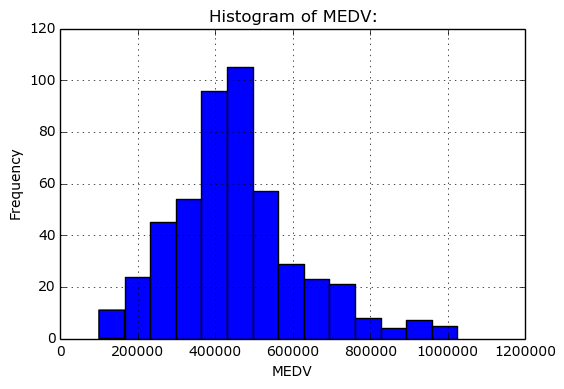

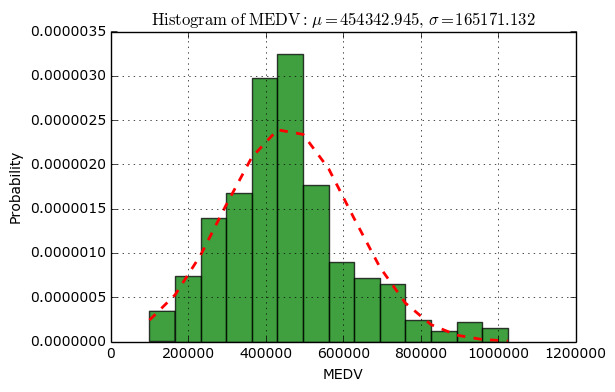

In [5]:
import math

# using np.histogram
n = data.shape[0]
bins = math.ceil(1.75 * (489 ** (1. / 3)))
class_range = (maximum_price - minimum_price) / bins
class_range = 100000
intervals = np.arange(100000, maximum_price, class_range)
histogram = np.histogram(prices, bins=bins, range=(100000, maximum_price))
print histogram

# plotting with pyplot
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline

# plt.hist passes it's arguments to np.histogram
# frequency histogram
n, bins, patches = plt.hist(prices, bins=bins, range=(100000, maximum_price), facecolor='blue')  

plt.title('Histogram of MEDV:')
plt.xlabel('MEDV')
plt.ylabel('Frequency')          
plt.grid(True)
plt.show()


# probability histogram
# best fit of data
mu, sigma =  norm.fit(prices)
# histogram
n, bins, patches = plt.hist(prices, bins=bins, range=(100000, maximum_price), normed=1, facecolor='green', alpha=0.75)  # plt.hist passes it's arguments to np.histogram
plt.title(r'$\mathrm{Histogram\ of\ MEDV:}\ \mu=%.3f,\ \sigma=%.3f$' %(mu, sigma))
plt.xlabel('MEDV')
plt.ylabel('Probability')          
plt.grid(True)
# add a 'best fit' line
y = mlab.normpdf( bins, mu, sigma)
l = plt.plot(bins, y, 'r--', linewidth=2)

plt.show()

### Statistics for 'RM'

In [6]:
# Minimum price of the data
minimum_rm = np.min(data['RM'])

# Maximum price of the data
maximum_rm = np.max(data['RM'])

# Mean price of the data
mean_rm = np.mean(data['RM'])

# Standard deviation of prices of the data
std_rm = np.std(data['RM'])

# Show the calculated statistics
print "Statistics for number of rooms - Boston housing dataset:\n"
print "Minimum rooms: {:,.2f}".format(minimum_rm)
print "Maximum rooms: {:,.2f}".format(maximum_rm)
print "Mean rooms: {:,.2f}".format(mean_rm)
print "Standard deviation of rooms: {:,.2f}".format(std_rm)

Statistics for number of rooms - Boston housing dataset:

Minimum rooms: 3.56
Maximum rooms: 8.40
Mean rooms: 6.24
Standard deviation of rooms: 0.64


### Statistics for 'LSTAT'

In [7]:
# Minimum price of the data
minimum_lstat = np.min(data['LSTAT'])

# Maximum price of the data
maximum_lstat = np.max(data['LSTAT'])

# Mean price of the data
mean_lstat = np.mean(data['LSTAT'])

# Standard deviation of prices of the data
std_lstat = np.std(data['LSTAT'])

# Show the calculated statistics
print "Statistics for level of poberty - Boston housing dataset:\n"
print "Minimum lstat: {:,.2f}".format(minimum_lstat)
print "Maximum lstat: {:,.2f}".format(maximum_lstat)
print "Mean lstat: {:,.2f}".format(mean_lstat)
print "Standard deviation of lstat: {:,.2f}".format(std_lstat)

Statistics for level of poberty - Boston housing dataset:

Minimum lstat: 1.98
Maximum lstat: 37.97
Mean lstat: 12.94
Standard deviation of lstat: 7.07


### Features statistics

In [8]:
features.describe()

,RM,LSTAT,PTRATIO
count,489.000000,489.000000,489.000000
mean,6.240288,12.939632,18.516564
std,0.643650,7.081990,2.111268
min,3.561000,1.980000,12.600000
25%,5.880000,7.370000,17.400000
50%,6.185000,11.690000,19.100000
75%,6.575000,17.120000,20.200000
max,8.398000,37.970000,22.000000


In [10]:
data.corr()

,RM,LSTAT,PTRATIO,MEDV
RM,1.000000,-0.612033,-0.304559,0.697209
LSTAT,-0.612033,1.000000,0.360445,-0.760670
PTRATIO,-0.304559,0.360445,1.000000,-0.519034
MEDV,0.697209,-0.760670,-0.519034,1.000000


#### NumPy's corrcoef with seaborn heat map

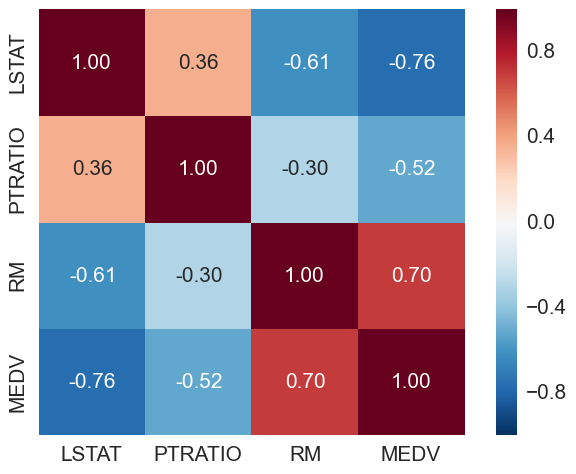

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cols = ['LSTAT', 'PTRATIO', 'RM', 'MEDV']
cm = np.corrcoef(data[cols].values.T)
sns.set(font_scale=1.5)
hm = sns.heatmap(cm,
                cbar=True,
                annot=True,
                square=True,
                fmt='.2f',
                annot_kws={'size': 15},
                yticklabels=cols,
                xticklabels=cols)
plt.show()

### Question 1 - Feature Observation
As a reminder, we are using three features from the Boston housing dataset: `'RM'`, `'LSTAT'`, and `'PTRATIO'`. For each data point (neighborhood):
- `'RM'` is the average number of rooms among homes in the neighborhood.
- `'LSTAT'` is the percentage of homeowners in the neighborhood considered "lower class" (working poor).
- `'PTRATIO'` is the ratio of students to teachers in primary and secondary schools in the neighborhood.

_Using your intuition, for each of the three features above, do you think that an increase in the value of that feature would lead to an **increase** in the value of `'MEDV'` or a **decrease** in the value of `'MEDV'`? Justify your answer for each._  
**Hint:** Would you expect a home that has an `'RM'` value of 6 be worth more or less than a home that has an `'RM'` value of 7?

**Answer: **
1. 'RM'
An increase of the value of 'RM' should increase the value of 'MEDV', since there are probably bigger dwellings in that neighborhood and bigger dwellings cost more money. 
2. 'LSTAT' 
A higher 'LSTAT' would probably represent a poorer neighborhood therefore the target variable ('MEDV') would decrease if 'LSTAT' increases. 
3. 'PTRATIO'
Using my intuition is uncertain what an increase of 'PTRATIO' would generate on the 'MEDV' variable.

#### Features vs MEDV housing prices

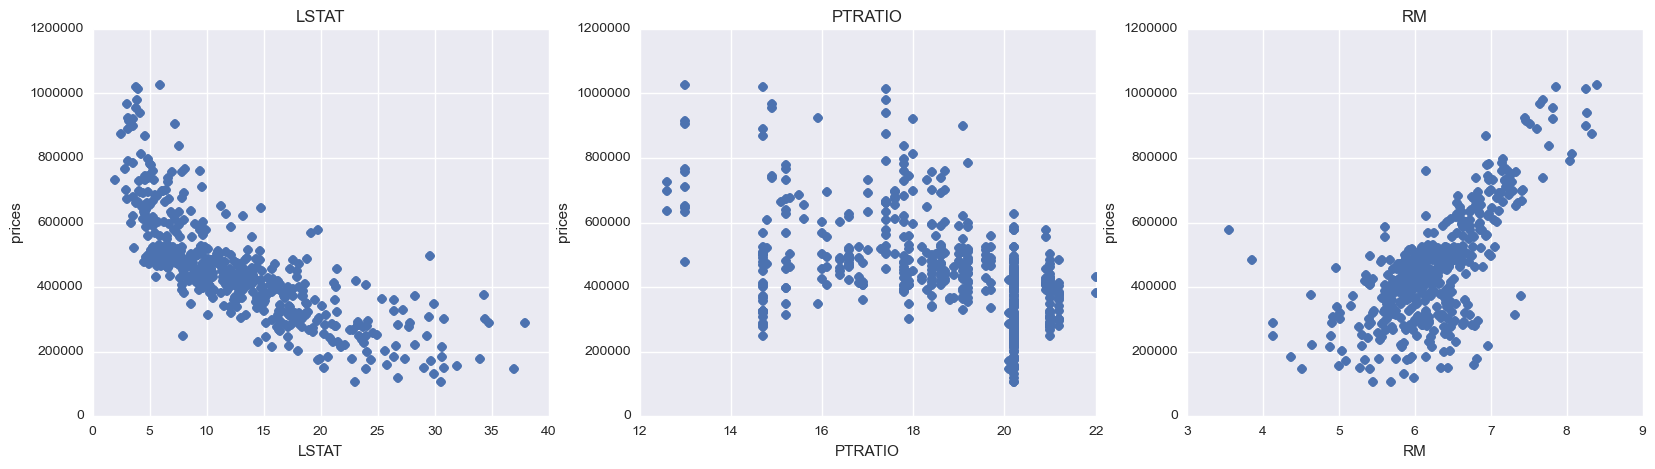

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 5))
for i, col in enumerate(features.columns):
    plt.subplot(1, 3, i)
    plt.plot(data[col], prices, 'o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('prices')

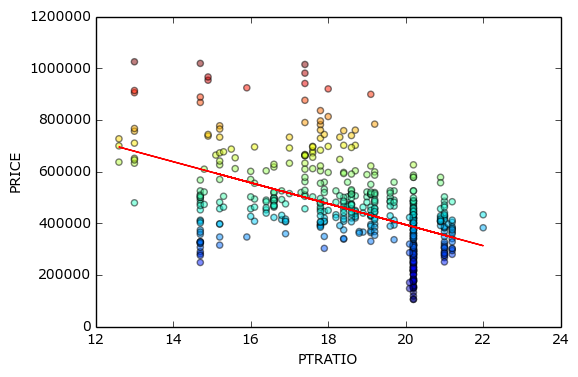

In [10]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
pt_ratio = data['PTRATIO'].reshape(-1, 1)
reg.fit(pt_ratio, prices)
plt.plot(pt_ratio, reg.predict(pt_ratio), color='red', linewidth=1)
plt.scatter(pt_ratio, prices, alpha=0.5, c=prices)
plt.xlabel('PTRATIO')
plt.ylabel('PRICE')
plt.show()

3. 'PTRATIO'

Based on the previous graphs PTRATIO may be inversely correlated.

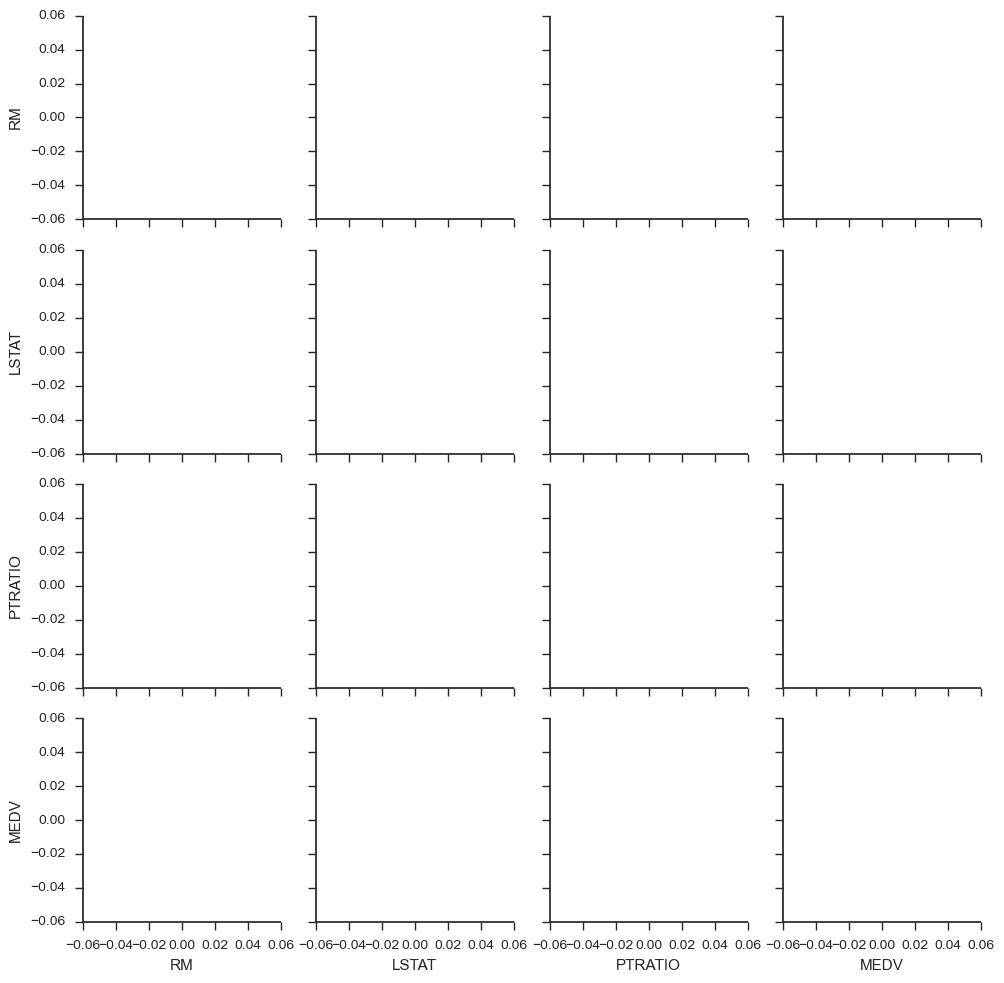

In [4]:
# Pairplot
%matplotlib inline
import seaborn as sns
sns.set(style="ticks", color_codes=True)
g = sns.pairplot(data)

----

## Developing a Model
In this second section of the project, you will develop the tools and techniques necessary for a model to make a prediction. Being able to make accurate evaluations of each model's performance through the use of these tools and techniques helps to greatly reinforce the confidence in your predictions.

### Implementation: Define a Performance Metric
It is difficult to measure the quality of a given model without quantifying its performance over training and testing. This is typically done using some type of performance metric, whether it is through calculating some type of error, the goodness of fit, or some other useful measurement. For this project, you will be calculating the [*coefficient of determination*](http://stattrek.com/statistics/dictionary.aspx?definition=coefficient_of_determination), R<sup>2</sup>, to quantify your model's performance. The coefficient of determination for a model is a useful statistic in regression analysis, as it often describes how "good" that model is at making predictions. 

The values for R<sup>2</sup> range from 0 to 1, which captures the percentage of squared correlation between the predicted and actual values of the **target variable**. A model with an R<sup>2</sup> of 0 is no better than a model that always predicts the *mean* of the target variable, whereas a model with an R<sup>2</sup> of 1 perfectly predicts the target variable. Any value between 0 and 1 indicates what percentage of the target variable, using this model, can be explained by the **features**. _A model can be given a negative R<sup>2</sup> as well, which indicates that the model is **arbitrarily worse** than one that always predicts the mean of the target variable._

For the `performance_metric` function in the code cell below, you will need to implement the following:
- Use `r2_score` from `sklearn.metrics` to perform a performance calculation between `y_true` and `y_predict`.
- Assign the performance score to the `score` variable.

In [2]:
# TODO: Import 'r2_score'
from sklearn.metrics import r2_score

def performance_metric(y_true, y_predict):
    """ Calculates and returns the performance score between 
        true and predicted values based on the metric chosen. """
    
    # TODO: Calculate the performance score between 'y_true' and 'y_predict'
    score = r2_score(y_true, y_predict)
    
    # Return the score
    return score

### Question 2 - Goodness of Fit
Assume that a dataset contains five data points and a model made the following predictions for the target variable:

| True Value | Prediction |
| :-------------: | :--------: |
| 3.0 | 2.5 |
| -0.5 | 0.0 |
| 2.0 | 2.1 |
| 7.0 | 7.8 |
| 4.2 | 5.3 |
*Would you consider this model to have successfully captured the variation of the target variable? Why or why not?* 

Run the code cell below to use the `performance_metric` function and calculate this model's coefficient of determination.

In [3]:
# Calculate the performance of this model
score = performance_metric([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])
print "Model has a coefficient of determination, R^2, of {:.3f}.".format(score)

Model has a coefficient of determination, R^2, of 0.923.


**Answer: **
Yes, this model captures successfully the variation of the target variable because the r2 score is 0.923 which means it explains 92.3% of the total variability of the target variable.

#### Linear relationship between the 'True Values' and 'Predictions' 

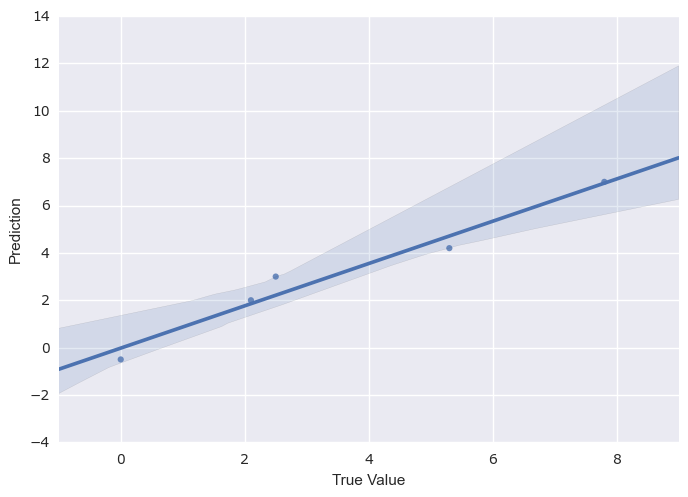

In [57]:
# Seaborn is a Python visualization library based on matplotlib. 
# http://seaborn.pydata.org/tutorial/regression.html
import seaborn as sns
sample_df = pd.DataFrame([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3]).reset_index()
sample_df.columns = ['True Value', 'Prediction']
sns.regplot('True Value', 'Prediction', sample_df)

### Implementation: Shuffle and Split Data
Your next implementation requires that you take the Boston housing dataset and split the data into training and testing subsets. Typically, the data is also shuffled into a random order when creating the training and testing subsets to remove any bias in the ordering of the dataset.

For the code cell below, you will need to implement the following:
- Use `train_test_split` from `sklearn.cross_validation` to shuffle and split the `features` and `prices` data into training and testing sets.
  - Split the data into 80% training and 20% testing.
  - Set the `random_state` for `train_test_split` to a value of your choice. This ensures results are consistent.
- Assign the train and testing splits to `X_train`, `X_test`, `y_train`, and `y_test`.

In [4]:
# TODO: Import 'train_test_split'

from sklearn.cross_validation import train_test_split

# TODO: Shuffle and split the data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
        features, prices, test_size=0.2, random_state=2
    )

# Success
print "Training and testing split was successful."

Training and testing split was successful.


### Question 3 - Training and Testing
*What is the benefit to splitting a dataset into some ratio of training and testing subsets for a learning algorithm?*  
**Hint:** What could go wrong with not having a way to test your model?

**Answer: **
The training dataset is used to find the model that successfully captures the variation of the target variable. Then this model is applied to a test set (unseen data) and the performance metrics of the model are calculated. This metrics can show if the model is underfitting or overfitting. If all the data was to be use in the training set then there would be no way to know the model bias (underfitting) and variance (overfitting).

http://docs.aws.amazon.com/machine-learning/latest/dg/splitting-the-data-into-training-and-evaluation-data.html

----

## Analyzing Model Performance
In this third section of the project, you'll take a look at several models' learning and testing performances on various subsets of training data. Additionally, you'll investigate one particular algorithm with an increasing `'max_depth'` parameter on the full training set to observe how model complexity affects performance. Graphing your model's performance based on varying criteria can be beneficial in the analysis process, such as visualizing behavior that may not have been apparent from the results alone.

### Learning Curves
The following code cell produces four graphs for a decision tree model with different maximum depths. Each graph visualizes the learning curves of the model for both training and testing as the size of the training set is increased. Note that the shaded region of a learning curve denotes the uncertainty of that curve (measured as the standard deviation). The model is scored on both the training and testing sets using R<sup>2</sup>, the coefficient of determination.  

Run the code cell below and use these graphs to answer the following question.

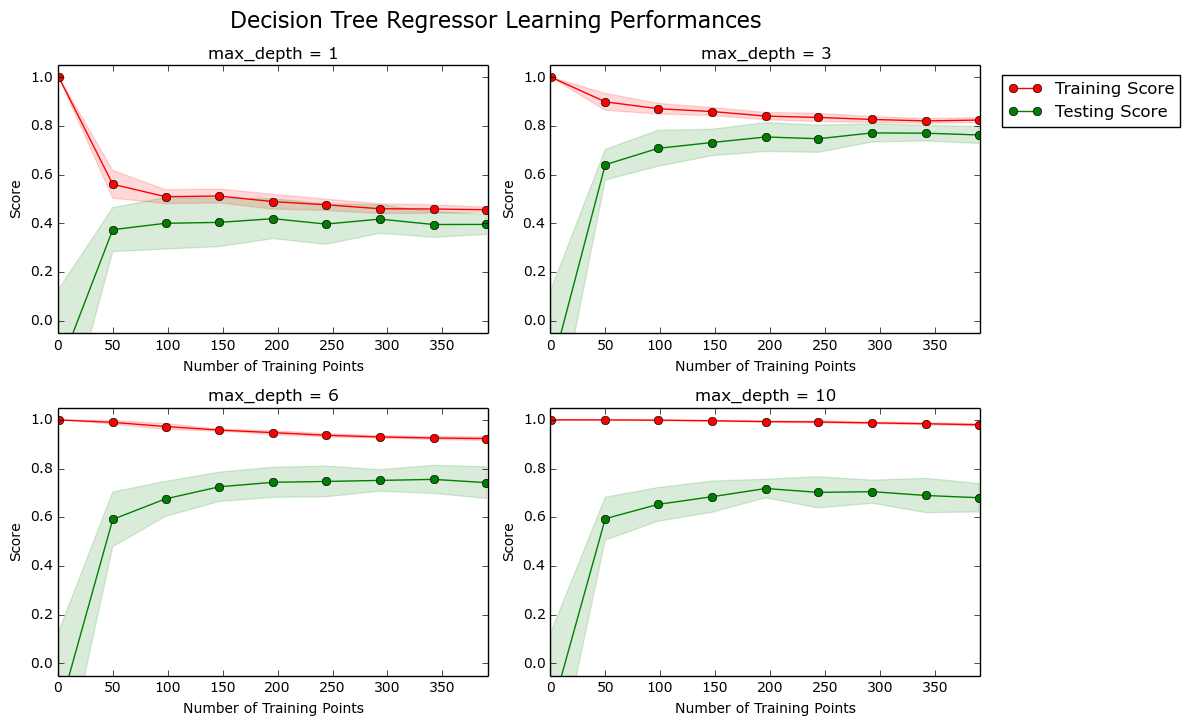

In [5]:
# Produce learning curves for varying training set sizes and maximum depths
vs.ModelLearning(features, prices)

### Question 4 - Learning the Data
*Choose one of the graphs above and state the maximum depth for the model. What happens to the score of the training curve as more training points are added? What about the testing curve? Would having more training points benefit the model?*  
**Hint:** Are the learning curves converging to particular scores?

**Answer: **
* Graph chosen: max_depth = 3.
* As more training points are added the score of the training point decreases. In the case of the testing curve increases. There is a  maximum number of training points from which the model can’t improve substantially. That is the model has learned as much as it can. There is an optimal max_depth. In the 4 graphs shown the optimal max_depth is 3, because the training and testing curve converge to a high value of r2. That means a better generalization of the model with a small gap (low variance).

### Complexity Curves
The following code cell produces a graph for a decision tree model that has been trained and validated on the training data using different maximum depths. The graph produces two complexity curves — one for training and one for validation. Similar to the **learning curves**, the shaded regions of both the complexity curves denote the uncertainty in those curves, and the model is scored on both the training and validation sets using the `performance_metric` function.  

Run the code cell below and use this graph to answer the following two questions.

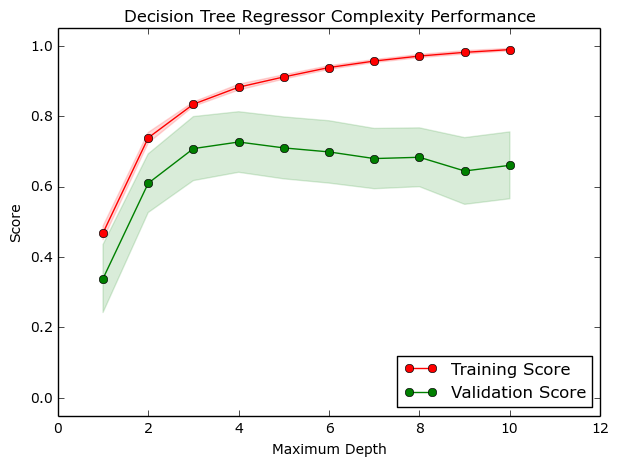

In [6]:
vs.ModelComplexity(X_train, y_train)

### Question 5 - Bias-Variance Tradeoff
*When the model is trained with a maximum depth of 1, does the model suffer from high bias or from high variance? How about when the model is trained with a maximum depth of 10? What visual cues in the graph justify your conclusions?*  
**Hint:** How do you know when a model is suffering from high bias or high variance?

**Answer: **
1. Training the model with a max_depth of 1 produces a high bias, that is the model is underfitting. In the graph can be observed that there is a small gap between the training and validation scores (low variance). But a score of approximately 0.5 means the model explain only 50% of the total variability of the target variable.
2. When the model is trained with a max_depth of 10, the model has a high variance. This variance is indicated by the big gap between the testing and validation score.

Bias-Variance Dilemma (image from Udacity's Machine Learning Nanodegree): 
![Bias-Variance Dilemma](https://udacity-github-sync-content.s3.amazonaws.com/_attachments/19273/1482721811/5.jpg)


### Question 6 - Best-Guess Optimal Model
*Which maximum depth do you think results in a model that best generalizes to unseen data? What intuition lead you to this answer?*

**Answer: **
The optimal max_depth is 3, because the training and testing curve converge to a high value of r2 (that means a better generalization of the model) and there is a small gap (low variance).

-----

## Evaluating Model Performance
In this final section of the project, you will construct a model and make a prediction on the client's feature set using an optimized model from `fit_model`.

### Question 7 - Grid Search
*What is the grid search technique and how it can be applied to optimize a learning algorithm?*

**Answer: **

The grid search technique is an exhaustive search that puts in a grid every combination of the provided parameters. Usually those parameters are passed to the k-fold cross-validation training technique that trains each of the resulting models and evaluate them using cross-validation. Then the one that performed best can be selected.

**From review: **

One limitation of GridSearch is that it can be very computationally expensive when dealing with a large number of different hyperparameters and much bigger datasets. Therefore there are two other techniques that we could explore to validate our hyperparameters:

* [RandomizedSearchCV](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#sklearn.model_selection.RandomizedSearchCV) which can sample a given number of candidates from a parameter space with a specified distribution. Which performs surprisingly well!

* Or a train / validation / test split, and we can validate our model on the validation set. Often used with much bigger datasets

https://en.wikipedia.org/wiki/Hyperparameter_optimization

### Question 8 - Cross-Validation
*What is the k-fold cross-validation training technique? What benefit does this technique provide for grid search when optimizing a model?*  
**Hint:** Much like the reasoning behind having a testing set, what could go wrong with using grid search without a cross-validated set?

**Answer: **
The k-fold cross-validation training technique splits the training set into k-1 parts and the testing set into one part. Then the model is trained and tested with the testing set. This process is repeated k times. Therefore, all the data is used for training and the average of the model is calculated as an average of the performance of the k test sets. If the grid search where to be used without a cross-validated set, one could infer that a set of parameters are better than other sets for obtaining the model, this could not be true since the size of the testing and test set itself also influence the performance metrics of the model.

### Implementation: Fitting a Model
Your final implementation requires that you bring everything together and train a model using the **decision tree algorithm**. To ensure that you are producing an optimized model, you will train the model using the grid search technique to optimize the `'max_depth'` parameter for the decision tree. The `'max_depth'` parameter can be thought of as how many questions the decision tree algorithm is allowed to ask about the data before making a prediction. Decision trees are part of a class of algorithms called *supervised learning algorithms*.

In addition, you will find your implementation is using `ShuffleSplit()` for an alternative form of cross-validation (see the `'cv_sets'` variable). While it is not the K-Fold cross-validation technique you describe in **Question 8**, this type of cross-validation technique is just as useful!. The `ShuffleSplit()` implementation below will create 10 (`'n_iter'`) shuffled sets, and for each shuffle, 20% (`'test_size'`) of the data will be used as the *validation set*. While you're working on your implementation, think about the contrasts and similarities it has to the K-fold cross-validation technique.

For the `fit_model` function in the code cell below, you will need to implement the following:
- Use [`DecisionTreeRegressor`](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) from `sklearn.tree` to create a decision tree regressor object.
  - Assign this object to the `'regressor'` variable.
- Create a dictionary for `'max_depth'` with the values from 1 to 10, and assign this to the `'params'` variable.
- Use [`make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) from `sklearn.metrics` to create a scoring function object.
  - Pass the `performance_metric` function as a parameter to the object.
  - Assign this scoring function to the `'scoring_fnc'` variable.
- Use [`GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) from `sklearn.grid_search` to create a grid search object.
  - Pass the variables `'regressor'`, `'params'`, `'scoring_fnc'`, and `'cv_sets'` as parameters to the object. 
  - Assign the `GridSearchCV` object to the `'grid'` variable.

In [19]:
# TODO: Import 'make_scorer', 'DecisionTreeRegressor', and 'GridSearchCV'
from sklearn.metrics import make_scorer
from sklearn.tree import DecisionTreeRegressor
from sklearn import grid_search

def fit_model(X, y):
    """ Performs grid search over the 'max_depth' parameter for a 
        decision tree regressor trained on the input data [X, y]. """
    
    # Create cross-validation sets from the training data
    cv_sets = ShuffleSplit(X.shape[0], n_iter = 10, test_size = 0.20, random_state = 0)

    # TODO: Create a decision tree regressor object
    regressor = DecisionTreeRegressor(random_state = 2)

    # TODO: Create a dictionary for the parameter 'max_depth' with a range from 1 to 10
    max_depth_range = range(1, 11)
    params = dict(max_depth=max_depth_range)

    # TODO: Transform 'performance_metric' into a scoring function using 'make_scorer' 
    # performance_metric returns r2 score
    scoring_fnc = make_scorer(performance_metric)

    # TODO: Create the grid search object
    grid = grid_search.GridSearchCV(regressor, params, cv=cv_sets, scoring=scoring_fnc)

    # Fit the grid search object to the data to compute the optimal model
    grid = grid.fit(X, y)

    # Return the optimal model after fitting the data
    return grid.best_estimator_
fit_model(features, prices)

/usr/local/lib/python2.7/dist-packages/sklearn/grid_search.py:43: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. This module will be removed in 0.20.
  DeprecationWarning)


DecisionTreeRegressor(criterion='mse', max_depth=4, max_features=None,
           max_leaf_nodes=None, min_impurity_split=1e-07,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, presort=False, random_state=2,
           splitter='best')

### Making Predictions
Once a model has been trained on a given set of data, it can now be used to make predictions on new sets of input data. In the case of a *decision tree regressor*, the model has learned *what the best questions to ask about the input data are*, and can respond with a prediction for the **target variable**. You can use these predictions to gain information about data where the value of the target variable is unknown — such as data the model was not trained on.

### Question 9 - Optimal Model
_What maximum depth does the optimal model have? How does this result compare to your guess in **Question 6**?_  

Run the code block below to fit the decision tree regressor to the training data and produce an optimal model.

In [20]:
# Fit the training data to the model using grid search
reg = fit_model(X_train, y_train)

# Produce the value for 'max_depth'
print "Parameter 'max_depth' is {} for the optimal model.".format(reg.get_params()['max_depth'])

Parameter 'max_depth' is 4 for the optimal model.


**Answer: **
The model has an optimal depth of 4, my guess of 3 was close to the optimal value.

### Question 10 - Predicting Selling Prices
Imagine that you were a real estate agent in the Boston area looking to use this model to help price homes owned by your clients that they wish to sell. You have collected the following information from three of your clients:

| Feature | Client 1 | Client 2 | Client 3 |
| :---: | :---: | :---: | :---: |
| Total number of rooms in home | 5 rooms | 4 rooms | 8 rooms |
| Neighborhood poverty level (as %) | 17% | 32% | 3% |
| Student-teacher ratio of nearby schools | 15-to-1 | 22-to-1 | 12-to-1 |
*What price would you recommend each client sell his/her home at? Do these prices seem reasonable given the values for the respective features?*  
**Hint:** Use the statistics you calculated in the **Data Exploration** section to help justify your response.  

Run the code block below to have your optimized model make predictions for each client's home.

In [21]:
# Produce a matrix for client data
client_data = [[5, 17, 15], # Client 1
               [4, 32, 22], # Client 2
               [8, 3, 12]]  # Client 3

# Show predictions
for i, price in enumerate(reg.predict(client_data)):
    print "Predicted selling price for Client {}'s home: ${:,.2f}".format(i+1, price)

Predicted selling price for Client 1's home: $415,800.00
Predicted selling price for Client 2's home: $236,478.26
Predicted selling price for Client 3's home: $888,720.00


**Answer: **
Recommended prices:

Client 1: $415,800.00
Reasonable, since price, number of rooms and poverty level are close to the mean.

Client 2: $236,478.26
Reasonable, level of poverty is really high.

Client 3: $888,720.00
Reasonable, number of rooms are near the maximum value and there is a really low level of poverty.

**From Data Exploration:**

Minimum price: $105,000.00 

Maximum price: $1,024,800.00

Mean price: $454,342.94

Median price $438,900.00

Standard deviation of prices: $165,171.13

Lower limit of 2 std: $124,000.68

Upper limit of 2 std: $784,685.21

Mode: $784,685.21

**Statistics for number of rooms in Boston housing dataset: **

Minimum rooms: 3.56

Maximum rooms: 8.40

Mean rooms: 6.24

Standard deviation of rooms: 0.64

**Statistics for level of poverty in Boston housing dataset: **

Minimum lstat: 1.98

Maximum lstat: 37.97

Mean lstat: 12.94

Standard deviation of lstat: 7.07

#### Predictions in histogram ('MEDV')

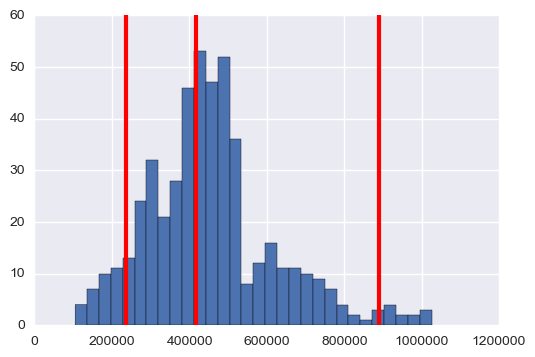

In [22]:
import matplotlib.pyplot as plt
plt.hist(prices, bins = 30)
for price in reg.predict(client_data):
    plt.axvline(price, c = 'r', lw = 3)

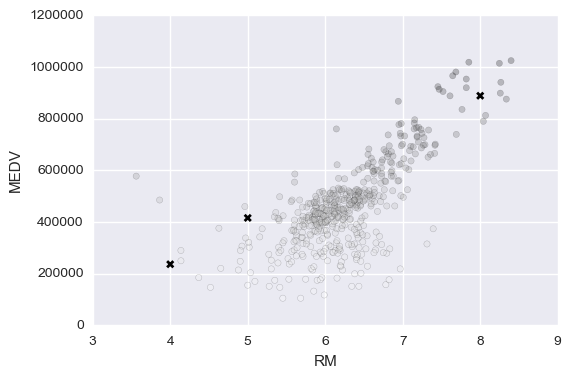

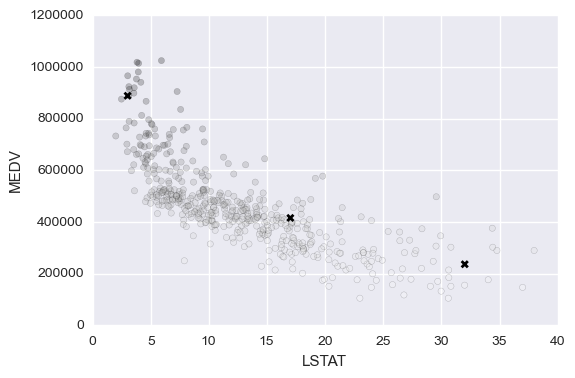

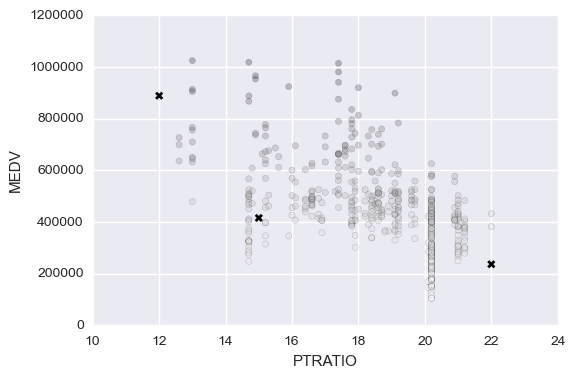

In [24]:
from matplotlib import pyplot as plt

clients = np.transpose(client_data)
pred = reg.predict(client_data)
for i, feat in enumerate(['RM', 'LSTAT', 'PTRATIO']):
    plt.scatter(features[feat], prices, alpha=0.25, c=prices)
    plt.scatter(clients[i], pred, color='black', marker='x', linewidths=2)
    plt.xlabel(feat)
    plt.ylabel('MEDV')
    plt.show()

### Sensitivity
An optimal model is not necessarily a robust model. Sometimes, a model is either too complex or too simple to sufficiently generalize to new data. Sometimes, a model could use a learning algorithm that is not appropriate for the structure of the data given. Other times, the data itself could be too noisy or contain too few samples to allow a model to adequately capture the target variable — i.e., the model is underfitted. Run the code cell below to run the `fit_model` function ten times with different training and testing sets to see how the prediction for a specific client changes with the data it's trained on.

In [22]:
vs.PredictTrials(features, prices, fit_model, client_data)

Trial 1: $391,183.33
Trial 2: $419,700.00
Trial 3: $415,800.00
Trial 4: $420,622.22
Trial 5: $418,377.27
Trial 6: $411,931.58
Trial 7: $399,663.16
Trial 8: $407,232.00
Trial 9: $351,577.61
Trial 10: $413,700.00

Range in prices: $69,044.61


### Question 11 - Applicability
*In a few sentences, discuss whether the constructed model should or should not be used in a real-world setting.*  
**Hint:** Some questions to answering:
- *How relevant today is data that was collected from 1978?*
- *Are the features present in the data sufficient to describe a home?*
- *Is the model robust enough to make consistent predictions?*
- *Would data collected in an urban city like Boston be applicable in a rural city?*

**Answer: **
* Data collected from 1978 should be scaled to account for the market inflation, a net present value function should be applied to the data. Nevertheless, the data may not be relevant (demographics may have changed over the years).
* Other features such as crime rates, level of education, health care, etc. could be trained and tested in a new model and see how well their performances are.
* The model predicted 70% of the variability but only has three features and 489 entries. Since the features and the sample are not large enough the model should not be used in a real-world setting.
* Data from an urban city may not be applicable to a rural city because demographics, prices, etc. most likely are not the same.
